In [ ]:
%pip install "sunpy[all]"
%pip install ipywidgets

In [1]:
from datetime import timedelta
 
import astropy.units as u
from astropy.time import Time

from sunpy.net import Fido, attrs as a
from sunpy.coordinates import frames

from astropy.coordinates import SkyCoord
from astropy import units as u

import matplotlib.pyplot as plt
import sunpy.map 
import numpy as np

import extract_metadata_info as exs
import re

In [3]:
test_data = {
  "paper": "paper_2620529.pdf",
  "paper_authors": "Labrosse, N",
  "paper_title": "Plasma diagnostic in eruptive prominences from SDO/AIA observations at 304 Å",
  "observations": [
    {
      "observation_filename": "solar_001_p3_aia_false_color",
      "figure": 2,
      "caption": "Fig. 2. Top: Evolution of the 2010-06-13 prominence eruption. The circle marks the part of the prominence which was tracked and used to calculate the intensities. The ﬁeld of view in the im- ages is 300′′×300′′. Bottom: Variation of relative intensity as a function of velocity in the plane of the sky. Intensities are nor- malised by the intensity corresponding to the lowest velocity. The inset shows the relative intensity variation with axis scales speciﬁc to this event. The time evolution is coded in color (with the time-scale indicated on the right of the plot) in the online version of the ﬁgure. 2.4. Prominence eruption on 2011-06-10 at 17:43 This prominence eruption took place on the 10th June 2011 and was associated to a C2.9 ﬂare in AR 11227. First appearing as a compact ﬂaring region on the south west limb, the promi- nence soon developed into a very tight looped structure at around 17:49, very diﬀerent to the other cases explored here. This is a good example of a so-called failed eruption, with most of the plasma falling back towards the surface of the Sun. For this particular prominence, two parts were tracked. The ﬁrst feature-tracking started at 17:48 on the part of the loop which evolves into the jet of plasma. The feature was tracked over 10 images, ending at 17:57. The second blob of plasma is chosen in a diﬀerent part of the prominence. Tracking started at 17:52 for 10 images, ending at 18:01. Figure 5 shows the same information as Figure 2 only for the 2011-06-10 event. In this case however the ﬁrst tracked feature is indicated in the ﬁrst three images in the sequence, while the last three images show the second feature.",
      "paragraphs": [
        "about log T = 4.7. In that passband, however, lies another line at 303.3 Å emitted by Si xi (see Sect. 4.1). The main advantage of AIA over previous solar imagers is both its high spatial and tem- poral resolutions. The apparatus uses a 4096×4096 CCD chip with a pixel size of 0.6′′ (level 1.5 data), allowing it to probe into the ﬁne structures of the Sun. AIA takes an image approximately every 12 seconds at each wavelength, allowing it to closely track even the most rapidly evolving features – which is useful for our investigation. We select four events in the SDO/AIA database. The main selection criteria are that the eruptions must be well developed and last long enough to facilitate manual feature tracking. We choose four events exhibiting diﬀerent morphologies. In each case, we produce a movie (available on request) from the level 1.5 data and follow individual features. Intensities are averaged over nine pixels to produce the intensity plots shown below (Figs 2–5). All intensities are normalised by the exposure time (2.9 s). In order to make the comparison with the theoretical in- tensities presented in Sect. 3, the observed intensities are nor- malised by the intensity corresponding to the lowest velocity. Hence all intensity values greater than 1 indicate that a brighten- ing of the prominence with velocity, while intensity values lower than 1 indicate a dimming of the prominence with velocity. The variation of the relative intensity as a function of velocity shown in the bottom panels of Figs 2–5 has been plotted with the same axis scales in intensity and velocity for the four events in order to ease the comparison between each of them. In Fig. 2 an in- set has been added to show this intensity variation on a more appropriate scale for this speciﬁc event. Figure 1 shows the evolution of the velocity of selected fea- tures in four distinct eruptive prominences as a function of time elapsed since the beginning of tracking. This gives an overview of the dynamics of the selected events. While most of them evolve quite rapidly (reaching velocities larger than 100 km s−1 within a few minutes), the prominence eruption observed on 13 June 2010 is much less dynamic, with velocities of a few tens km s−1 after 1–2 hours. The following subsections present the details of individual events used in this work, and the intensity variations as a func- tion of velocity for the selected features.",
        "This moderate-sized prominence eruption takes place on the 13th June 2010 at 00:00 on the North-West limb. For the ﬁrst few hours of the event there is a slow rise phase. From around 03:00 onwards however the top part of the prominence begins to detach itself from the base as the motion becomes more promi- nent. At around 05:00 there is a clear detachment of the struc- ture and this then moves outward. This rise continues for several hours until it suddenly stretches before fading away. The base of the prominence rises by a small amount during this time, and then blows away and disappears from view. This eruption has been recently studied by R´egnier et al. (2011) who investigated the thermal and magnetic structure of the coronal cavity located above the prominence. We start our feature tracking at 04:15 UT in the middle part of the prominence body, but close to the edge to the coronal cav- ity. Diﬀering from other events studied in this paper by being a substantially longer lasting, slower event, images were taken at 15 minute intervals. The tracking was taken over 11 images, ending at 06:45, just before the detached plasma is stretched. Figure 2 shows six images of the evolution of the eruptive promi- nence and the feature which was tracked, and the variation of relative intensity (normalised to the intensity at the lowest ve- locity over the tracking period) as a function of velocity. The circles on the images highlight the pixels used in calculating the intensities. The velocities are much lower in this event than in the others studied in this paper. This event shows a decrease of the observed intensity of the He ii 304 channel with an increasing velocity. The trend of an intensity decrease with increasing velocity is reminiscent of the Doppler dimming eﬀect as illustrated by the theoretical calcula- tions of Labrosse et al. (2007, 2008). However, these theoretical calculations were done by varying only the radial velocity of the moving prominence, and keeping all the plasma parameters constant throughout the activation / eruption. In fact, we do not exclude that the physical parameters of the prominence plasma may vary during the eruption.",
        "This prominence eruption took place on September 8th, 2010. The eruption began at approximately 22:30 UT at the north- west limb. It was associated with a GOES Class B3.4 ﬂare near AR 11105. Any appreciable outward motion of the plasma did not occur until approximately 23:08. The tracking starts at 23:11 over 14 frames until 23:24 at a one minute cadence. Figure 3 shows the same information as Figure 2 only for the 2010-09-08 event. Here again, the main feature of the relative intensity vs ve- locity graph is the decrease in intensity with increasing velocity.",
        "This other prominence eruption took place on the 19th March 2011. Beginning at 11:10 UT, AIA observed a large kinking loop eruption from AR 11171. Located in the south west quadrant of the Sun, this eruption exhibits a strong sweeping motion as it moves further south. Helical motions are visible in the promi- nence legs during the eruption. We start the manual tracking at 11:49 of a bright patch of plasma on the ridge of the prominence over 11 images ending at 11:59. Figure 4 shows the same infor- mation as Figure 2 only for the 2011-03-19 event. It highlights what was already visible in Figs. 2 and 3, namely that a decrease of intensity with velocity is observed during the eruption.",
        "This prominence eruption took place on the 10th June 2011 and was associated to a C2.9 ﬂare in AR 11227. First appearing as a compact ﬂaring region on the south west limb, the promi- nence soon developed into a very tight looped structure at around 17:49, very diﬀerent to the other cases explored here. This is a good example of a so-called failed eruption, with most of the plasma falling back towards the surface of the Sun. For this particular prominence, two parts were tracked. The ﬁrst feature-tracking started at 17:48 on the part of the loop which evolves into the jet of plasma. The feature was tracked over 10 images, ending at 17:57. The second blob of plasma is chosen in a diﬀerent part of the prominence. Tracking started at 17:52 for 10 images, ending at 18:01. Figure 5 shows the same information as Figure 2 only for the 2011-06-10 event. In this case however the ﬁrst tracked feature is indicated in the ﬁrst three images in the sequence, while the last three images show the second feature."
      ],
      "timestamp_start": "2011-06-10T17:48",
      "timestamp_end": "2011-06-10T17:57",
      "instrument": "AIA",
      "wavelength_angstrom": 304,
      "limb_position": "SW",
      "fov_arcsec": [
        300,
        300
      ],
      "center_tx_arcsec": None,
      "center_ty_arcsec": None,
      "phenomenon": "Prominence",
      "confidence": "medium"
    }]
}

In [4]:
EVENTS = {
  "AR": "Active Region",
  "CE": "CME",
  "CD": "Coronal Dimming",
  "CH": "Coronal Hole",
  "CW": "Coronal Wave",
  "FI": "Filament",
  "FE": "Filament Eruption",
  "FA": "Filament Activation",
  "FL": "Flare",
  "LP": "Loop",
  "OS": "Oscillation",
  "SS": "Sunspot",
  "EF": "Emerging Flux",
  "CJ": "Coronal Jet",
  "PG": "Plage",
  "SG": "Sigmoid",
  "SP": "Spray Surge",
  "CR": "Coronal Rain",
  "CC": "Coronal Cavity",
  "ER": "Eruption",
  "TO": "Topological Object",
  "BU": "UV Burst",
  "EE": "Explosive Event",
  "PB": "Prominence Bubble",
  "PT": "Peacock Tail",
  "EP": "SEPs",
  "IC": "ICMEs",
  "SR": "SIRs",
  "PR": "Prominence"
}

In [5]:
structure_find = test_data["observations"][0]

WINDOW = timedelta(seconds=20)
VALID_REGIONS = ["N","S","NE","SE","NW","SW","W","E"]

fits_dir = "C:\\Users\\julio\\OneDrive - Universidad Nacional de Colombia\\Documentos\\Maestria\\Nacional\\Proyecto Juanes\\test_fits\\"

In [6]:
t_start = structure_find["timestamp_start"]
t_end = structure_find["timestamp_end"]

# What to do when the initial time is empty
if t_start is None:
    if t_end is None:
        raise Exception("No se encuentra ninguna fecha asociada al evento ingresado")
    else:
        t_start = t_end

# What to do when the end time is empty 
if t_end is None:
    peak_time = Time(t_start)
    t_start = (peak_time - WINDOW).isot
    t_end = (peak_time + WINDOW).isot

# Take into considaration null instruments
instrument = structure_find["instrument"].lower() if structure_find["instrument"] is not None else "hmi"
wavelength = structure_find["wavelength_angstrom"] if structure_find["wavelength_angstrom"] is not None else None
results = Fido.search(
    a.Time(t_start, t_end),
    a.Instrument(instrument),
    a.Wavelength(int(wavelength)*u.angstrom)
)

files = []
for i in range(len(results[0])):
    filename = Fido.fetch(results[0,i], path=fits_dir)
    files.append(filename[0])

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [56]:
obs_submaps = []
for file in files:
    rmap = sunpy.map.Map(file)

    submaps = []
    if structure_find["center_tx_arcsec"] is not None and structure_find["center_ty_arcsec"] is not None:
        
        if structure_find["fov_arcsec"] is not None and len(structure_find["fov_arcsec"]) == 2:
            def_fov = structure_find["fov_arcsec"]
        else:
            def_fov = [180,180]

        center = (float(structure_find["center_tx_arcsec"]),float(structure_find["center_ty_arcsec"]))

        bottom_left = SkyCoord(
            center.Tx - def_fov[0] * u.arcsec,
            center.Ty - def_fov[1] * u.arcsec,
            frame=rmap.coordinate_frame
        )

        upper_right = SkyCoord(
            center.Tx + def_fov[0] * u.arcsec,
            center.Ty + def_fov[1] * u.arcsec,
            frame=rmap.coordinate_frame
        )

        submaps.append((rmap.submap(bottom_left, top_right=upper_right), center))

    else:

        tot_events = []
        for key in EVENTS:
            if f" {key} " in structure_find["phenomenon"] or EVENTS[key].lower() in structure_find["phenomenon"].lower():
                if key == "PR" and len(tot_events) == 0:
                    possible_events = ["FL","PB","ER","EE"]
                    for event in possible_events:
                        tot_events += exs.extract_events(rmap, t_start, t_end, event)
                        
                else:
                    tot_events += exs.extract_events(rmap, t_start, t_end, key)

        if len(tot_events) > 0 and structure_find["limb_position"] in VALID_REGIONS:
            
            if structure_find["fov_arcsec"] is not None and len(structure_find["fov_arcsec"]) == 2:
                def_fov = structure_find["fov_arcsec"]
            else:
                def_fov = [180,180]

            region_label = re.sub(r'[^a-zA-Z0-9]', '', structure_find["limb_position"])
            region_description = exs.extract_solar_regions(rmap)[structure_find["limb_position"]]

            region_events = [event for event in tot_events 
                            if event.Tx > region_description["tx_min"] 
                            and event.Tx < region_description["tx_max"]
                            and event.Ty > region_description["ty_min"] 
                            and event.Ty < region_description["ty_max"]]
            
            
            for event in region_events:
                
                bottom_left = SkyCoord(
                event.Tx - def_fov[0] * u.arcsec,
                event.Ty - def_fov[1] * u.arcsec,
                frame=rmap.coordinate_frame
                )

                upper_right = SkyCoord(
                    event.Tx + def_fov[0] * u.arcsec,
                    event.Ty + def_fov[1] * u.arcsec,
                    frame=rmap.coordinate_frame
                )

                submaps.append((rmap.submap(bottom_left, top_right=upper_right), event))


        elif len(tot_events) > 0 and structure_find["limb_position"] not in VALID_REGIONS:

            if structure_find["fov_arcsec"] is not None and len(structure_find["fov_arcsec"]) == 2:
                def_fov = structure_find["fov_arcsec"]
            else:
                def_fov = [180,180]

            for event in tot_events:
                
                bottom_left = SkyCoord(
                event.Tx - def_fov[0] * u.arcsec,
                event.Ty - def_fov[1] * u.arcsec,
                frame=rmap.coordinate_frame
                )

                upper_right = SkyCoord(
                    event.Tx + def_fov[0] * u.arcsec,
                    event.Ty + def_fov[1] * u.arcsec,
                    frame=rmap.coordinate_frame
                )
                submaps.append((rmap.submap(bottom_left, top_right=upper_right), event))
            
        elif structure_find["limb_position"] in VALID_REGIONS:
            
            if structure_find["fov_arcsec"] is not None and len(structure_find["fov_arcsec"]) == 2:
                def_fov = structure_find["fov_arcsec"]
            else:
                def_fov = [300,300]

            region_description = exs.extract_solar_regions(rmap)[structure_find["limb_position"]]
            submaps.append((rmap.submap(region_description["bottom_left"], top_right=region_description["top_right"]), region_description["weighted_center"]))
        
        else:
            submaps.append((rmap, None))

    obs_submaps.append(submaps)


In [99]:
imgs_dir = "C:\\Users\\julio\\OneDrive - Universidad Nacional de Colombia\\Documentos\\Maestria\\Nacional\\Proyecto Juanes\\test_fits\\"
image = "solar_014_p4_aia_false_color.png"

In [100]:
import cv2
import os

THREASHOLD = 0.8
def confidence(img, template):
    res = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)
    conf = res.max()
    return np.where(res == conf), conf

import numpy as np

def normalize_to_uint8(arr, scale_type='log', low_percentile=1, high_percentile=99.9):
    # 1. Handle NaN values first
    arr = np.nan_to_num(arr)
    
    # 2. Apply non-linear scaling to compress the dynamic range
    if scale_type == 'log':
        # Add a tiny value (1e-6) to avoid log(0)
        # Shift data if there are negative numbers after nan_to_num
        min_val = arr.min()
        if min_val < 0:
            arr = arr - min_val
        arr = np.log1p(arr) 
        
    elif scale_type == 'sqrt':
        # Ensure no negative values before square root
        arr = np.clip(arr, 0, None)
        arr = np.sqrt(arr)
        
    # 3. Calculate thresholds on the scaled data
    vmin = np.percentile(arr, low_percentile)
    vmax = np.percentile(arr, high_percentile)
    
    # 4. Saturate by clipping
    arr_clipped = np.clip(arr, vmin, vmax)
    
    # 5. Normalize to 0-255 range
    norm = (arr_clipped - vmin) / (vmax - vmin + 1e-9)
    return (norm * 255).astype(np.uint8)

i = 0
max_conf = 0
rec_coords = ()
timestep = 0
finded_structure = 0

template = cv2.imread(os.path.join(imgs_dir, image), cv2.IMREAD_GRAYSCALE)
h, w = template.shape

for t in range(len(obs_submaps)):
    submaps = obs_submaps[t]
    for l in range(len(submaps)):
        
        submap_info = submaps[l]
        submap, flare_coord = submap_info
        
        img = normalize_to_uint8(submap.data)
        ([y], [x]), conf = confidence(img, template)

        if conf > max_conf:
            max_conf = conf
            rec_coords = ([y], [x])
            timestep = t
            finded_structure = l


In [101]:
submap_info = obs_submaps[timestep][finded_structure]
submap, flare_coord = submap_info

img = normalize_to_uint8(submap.data)
([y], [x]), conf = confidence(img, template)

cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 2)
cv2.imshow("Test", img)    
cv2.imshow('Template', template)
cv2.waitKey(0)


-1

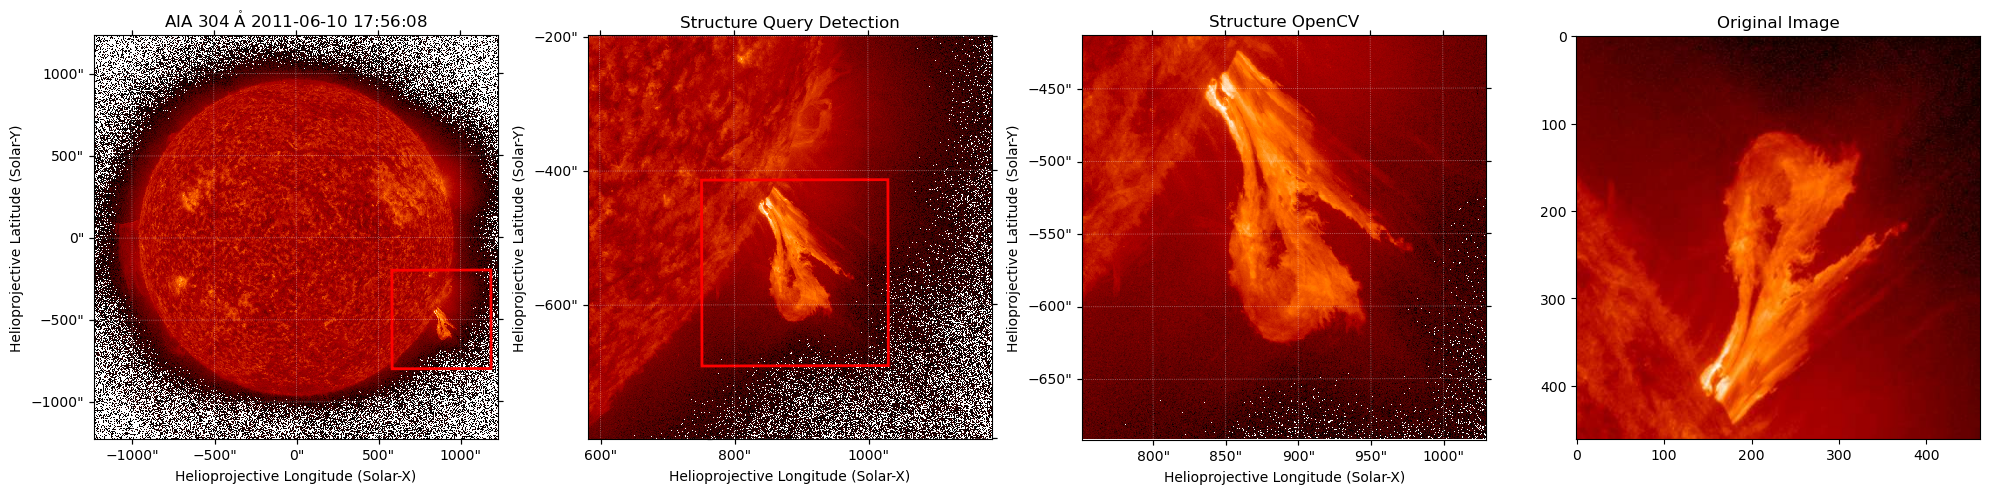

In [102]:
import matplotlib.colors as colors
from sunpy.coordinates import SphericalScreen

y, x = rec_coords

rmap = sunpy.map.Map(files[timestep])
rmap.plot_settings['norm'] = colors.LogNorm(1, rmap.max())
submap_info = obs_submaps[timestep][finded_structure]

submap, flare_coord = submap_info
submap.plot_settings['norm'] = colors.LogNorm(1, submap.max())

with SphericalScreen(submap.observer_coordinate, only_off_disk=True):
    bottom_left = submap.pixel_to_world(x[0]*u.pix, (y[0]+h)*u.pix)
    top_right = submap.pixel_to_world((x[0]+w)*u.pix, y[0]*u.pix)

opencv_sector = submap.submap(bottom_left=bottom_left, top_right=top_right)

fig = plt.figure(figsize=(20, 6))

ax1 = fig.add_subplot(1, 4, 1, projection=rmap)
rmap.plot(axes=ax1)
rmap.draw_quadrangle(
    submap.bottom_left_coord,
    top_right=submap.top_right_coord,
    axes=ax1,
    edgecolor='red',
    linewidth=2
)

ax2 = fig.add_subplot(1, 4, 2, projection=submap)
submap.plot(axes=ax2)
submap.draw_quadrangle(
    opencv_sector.bottom_left_coord,
    top_right=opencv_sector.top_right_coord,
    axes=ax2,
    edgecolor='red',
    linewidth=2
)
ax2.set_title("Structure Query Detection")

ax3 = fig.add_subplot(1, 4, 3, projection=opencv_sector)
opencv_sector.plot(axes=ax3)
ax3.set_title("Structure OpenCV")

original_image = cv2.imread(os.path.join(imgs_dir, image))
RGB_img = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
ax4 = fig.add_subplot(1, 4, 4)
ax4.set_title("Original Image")
ax4.imshow(RGB_img)

plt.tight_layout()
plt.show()
plt.close()


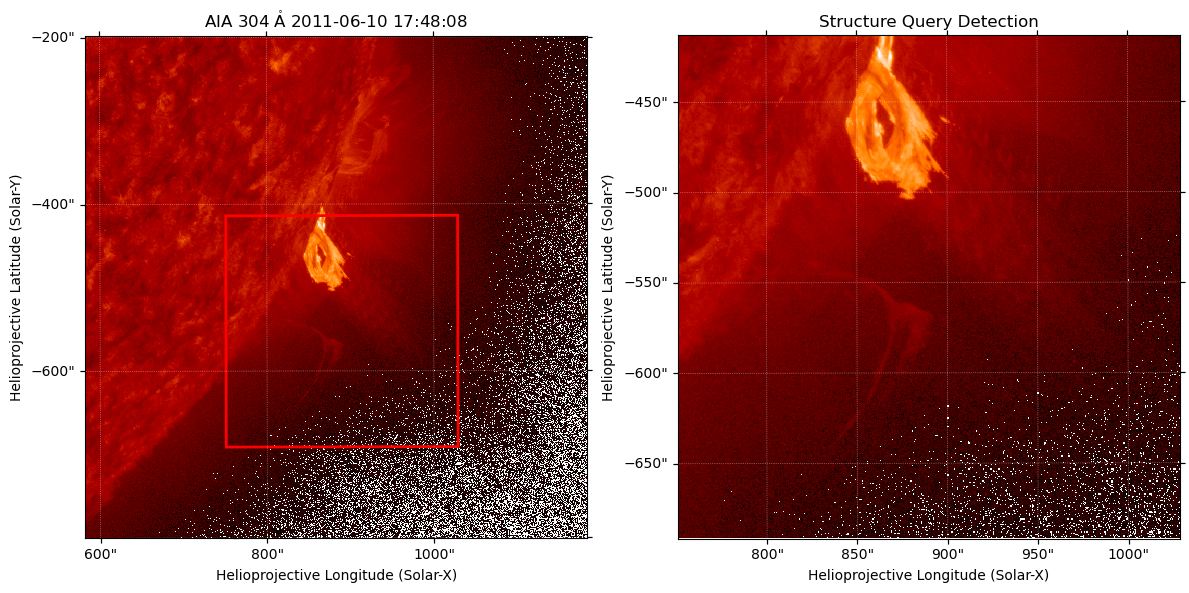

In [ ]:


submap_info = obs_submaps[timestep][finded_structure]

submap, flare_coord = submap_info
submap.plot_settings['norm'] = colors.LogNorm(1, submap.max())



fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1, projection=submap)
submap.plot(axes=ax1)
submap.draw_quadrangle(
    opencv_sector.bottom_left_coord,
    top_right=opencv_sector.top_right_coord,
    axes=ax1,
    edgecolor='red',
    linewidth=2
)

ax2 = fig.add_subplot(1, 2, 2, projection=opencv_sector)
opencv_sector.plot(axes=ax2)
ax2.set_title("Structure Query Detection")

plt.tight_layout()
plt.show()
plt.close()
#ax = fig.add_subplot(projection=opencv_sector)

#opencv_sector.plot(axes=ax)
#opencv_sector.draw_grid()

#plt.show()
#plt.close()

In [ ]:
import cv2
from skimage import io
import os

# Assume 'amap' and 'paper_img'/'original_image' defined upstream

# Step 1: RAW NORMALIZATION (critical fix!)
def preprocess_raw_continuum(amap_data):
    """Raw HMI continuum: abs(mag) -> normalized uint8, NO histeq"""
    data = np.abs(amap_data).astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    return cv2.normalize(data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Your paper image (keep as-is, but raw preprocess)
paper_img = io.imread(os.path.join(imgs_dir, "solar_016_p4_aia_false_color.png"), as_gray=True)

paper_gray = paper_img if paper_img.dtype == np.uint8 else (paper_img * 255).astype(np.uint8)

# RAW original (skip equalize_hist!)
submap, flare_coord, confidence = obs_submaps[0][0]
original_raw = preprocess_raw_continuum(submap.data)

print(f"Raw images ready. Paper shape: {paper_gray.shape}, Original: {original_raw.shape}")

# Step 2: Better denoising (bilateral preserves sunspot edges)
paper_denoised = cv2.bilateralFilter(paper_gray, 9, 75, 75)
original_denoised = cv2.bilateralFilter(original_raw, 9, 75, 75)

# Step 3: SIFT (more robust) + ORB fallback
def detect_features(img):
    """Try SIFT first, fallback to ORB"""
    try:
        sift = cv2.SIFT_create(nfeatures=3000)
        kp, des = sift.detectAndCompute(img, None)
        print("Using SIFT")
        return kp, des, 'SIFT'
    except:
        orb = cv2.ORB_create(nfeatures=5000, scaleFactor=1.2, nlevels=8)
        kp, des = orb.detectAndCompute(img, None)
        print("Using ORB")
        return kp, des, 'ORB'

kp_paper, des_paper, feat_type_paper = detect_features(paper_denoised)
kp_original, des_original, feat_type_original = detect_features(original_denoised)

print(f"Step 3 complete ({feat_type_paper}/{feat_type_original}): "
      f"{len(kp_paper)} keypoints (paper), {len(kp_original)} (original).")

# Step 4: Adaptive matching (stricter ratio test)
bf = cv2.BFMatcher(cv2.NORM_L2 if 'SIFT' in feat_type_paper else cv2.NORM_HAMMING, crossCheck=False)
matches_all = bf.knnMatch(des_paper, des_original, k=2)

# Stricter ratio test (0.7 -> 0.65) to reject text matches
good_matches = [m for m, n in matches_all if m.distance < 0.65 * n.distance]
print(f"Step 4 complete: {len(good_matches)} good matches (strict ratio=0.65).")

# Step 5: RANSAC (tighter threshold for sunspots)
if len(good_matches) > 10:  # Need more for robust fit
    src_pts = np.float32([kp_paper[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_original[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    M_sim, inlier_mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, 
                                                     method=cv2.RANSAC,
                                                     ransacReprojThreshold=3.0,  # Tighter
                                                     confidence=0.995)  # Higher confidence
    
    num_inliers = np.sum(inlier_mask)
    print(f"Step 5 complete: {num_inliers}/{len(good_matches)} inliers ({num_inliers/len(good_matches):.1%}).")
    
    if M_sim is not None and num_inliers > 15:  # Quality threshold
        h_paper, w_paper = paper_gray.shape
        h_orig, w_orig = original_raw.shape  # Use raw dims
        
        # Color for viz
        paper_color = cv2.cvtColor(paper_gray, cv2.COLOR_GRAY2BGR)
        original_color = cv2.cvtColor(original_raw, cv2.COLOR_GRAY2BGR)  # Raw color
        
        warped_paper = cv2.warpAffine(paper_color, M_sim, (w_orig, h_orig))
        overlay = cv2.addWeighted(original_color, 0.7, warped_paper, 0.3, 0)
        
        # Save
        cv2.imwrite('overlay_result_raw.jpg', overlay)
        cv2.imwrite('warped_paper_raw.jpg', warped_paper)
        
        # Matches viz (inliers only)
        good_inliers = [good_matches[i] for i in range(len(good_matches)) if inlier_mask[i]]
        match_img = cv2.drawMatches(paper_color, kp_paper, original_color, kp_original, 
                                    good_inliers[:50], None,
                                    matchColor=(0,255,0), singlePointColor=(255,0,0),
                                    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
        cv2.imwrite('match_visualization_raw.jpg', match_img)
        
        print("RAW Results saved: overlay_result_raw.jpg, etc.")
        print("Similarity matrix M:\n", M_sim)
        
        # Parameters
        cos_theta = M_sim[0,0]; sin_theta = M_sim[1,0]
        scale = np.sqrt(cos_theta**2 + sin_theta**2)
        angle_deg = np.degrees(np.arctan2(sin_theta, cos_theta))
        tx, ty = M_sim[0,2], M_sim[1,2]
        print(f"Scale: {scale:.3f}, Rotation: {angle_deg:.1f}°, Translation: ({tx:.1f}, {ty:.1f}) pix")
        
        match_img_exists = True
        M_sim_final = M_sim
        
    else:
        print("RANSAC failed (low inliers) - try SuperGlue next.")
        match_img_exists = False
        M_sim_final = None
else:
    print("Too few good matches.")
    match_img_exists = False
    M_sim_final = None

# Your rectangle/matched region code (unchanged, using M_sim_final)
if M_sim_final is not None:
    h_paper, w_paper = paper_gray.shape
    corners = np.float32([[0, 0], [w_paper, 0], [w_paper, h_paper], [0, h_paper]]).reshape(-1, 1, 2)
    transformed_corners = cv2.transform(corners, M_sim_final)
    transformed_corners = transformed_corners.astype(int)

    original_with_rect = cv2.cvtColor(original_raw, cv2.COLOR_GRAY2BGR)
    cv2.polylines(original_with_rect, [transformed_corners], isClosed=True, color=(0, 255, 0), thickness=3)
    cv2.imwrite('original_with_rectangle_raw.jpg', original_with_rect)

    # Matched region crop
    x_min, x_max = np.min(transformed_corners[:, 0, 0]), np.max(transformed_corners[:, 0, 0])
    y_min, y_max = np.min(transformed_corners[:, 0, 1]), np.max(transformed_corners[:, 0, 1])
    x_min, y_min = max(x_min, 0), max(y_min, 0)
    x_max, y_max = min(x_max, original_raw.shape[1]), min(y_max, original_raw.shape[0])
    matched_region = original_raw[int(y_min):int(y_max), int(x_min):int(x_max)]
    
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(original_with_rect, cv2.COLOR_BGR2RGB))
    plt.title('Detected Region (Raw Continuum)')
    plt.savefig('detected_region_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Matched region cropped: {matched_region.shape}")
else:
    matched_region = None

# Your 4-panel plot (adapted)
plt.figure(figsize=(20, 5))
plt.subplot(141); plt.imshow(paper_gray, cmap='gray'); plt.title('Paper (Raw)'); plt.colorbar()
plt.subplot(142); plt.imshow(original_raw, cmap='gray'); plt.title('Original Raw Continuum'); plt.colorbar()
plt.subplot(143)
if match_img_exists:
    plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
    plt.title('Inlier Matches (Green)')
else:
    plt.text(0.5, 0.5, 'No Good Matches', ha='center', va='center', fontsize=16)
    plt.title('Matches')
plt.subplot(144)
if matched_region is not None:
    plt.imshow(matched_region, cmap='gray')
    plt.title('Matched AR Region')
    plt.colorbar()
else:
    plt.text(0.5, 0.5, 'No Region', ha='center', va='center', fontsize=16)
    plt.title('Matched Region')

plt.tight_layout()
plt.savefig('keypoints_matches_region_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("Raw pipeline complete! Check *_raw.jpg files. If still poor → SuperGlue time.")


In [ ]:
def cluster_by_separation(coords, threshold):
    remaining = list(coords)
    clusters = []
    while remaining:
        seed = remaining.pop(0)
        group, rest = [seed], []
        for c in remaining:
            (group.append(c) if seed.separation(c) <= threshold else rest.append(c))
        clusters.append(SkyCoord(group))
        remaining = rest
    return clusters

groups = cluster_by_separation(coords, threshold=10*u.arcsec)

merged_coords = [
    SkyCoord(np.mean(g.Tx), np.mean(g.Ty), frame=g.frame[0])
    for g in groups
]